# **ASSIGNMENT-20: FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS**

# **Part 1: Data Preparation and Exploration**

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 1.)Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

In [2]:
df=pd.read_csv('exchange_rate.csv',index_col='date',parse_dates=True)
df

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


# 2.)Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

Text(0, 0.5, 'Exchange Rate')

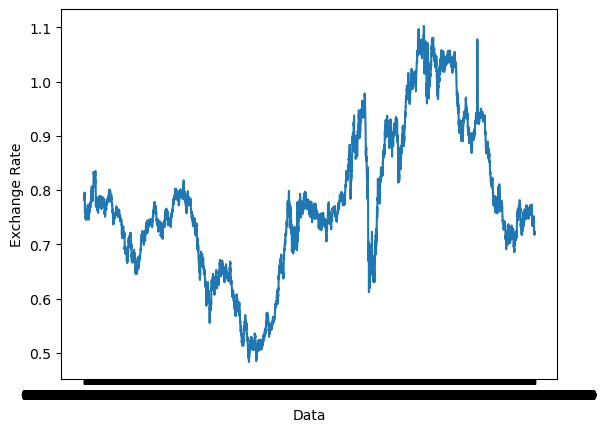

In [4]:
plt.plot(df)
plt.xlabel('Data')
plt.ylabel('Exchange Rate')

- The time series shows **high fluctuations and volatility** with noticeable trends over time.
- There is **no clear seasonal pattern,** but a **sharp drop and spike** indicate possible anomalies.
- The changing mean level suggests the data is **non-stationary,** requiring differencing for modeling.

# 3.)Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [5]:
# Missing Values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [6]:
# Duplicates
df.duplicated().sum()

np.int64(2258)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# **Part 2: Model Building - ARIMA**

# 1.)Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

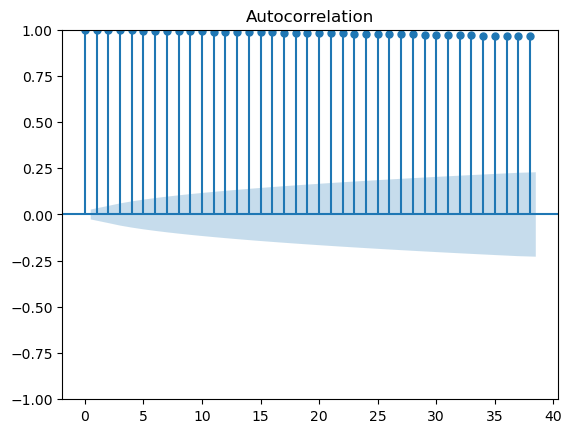

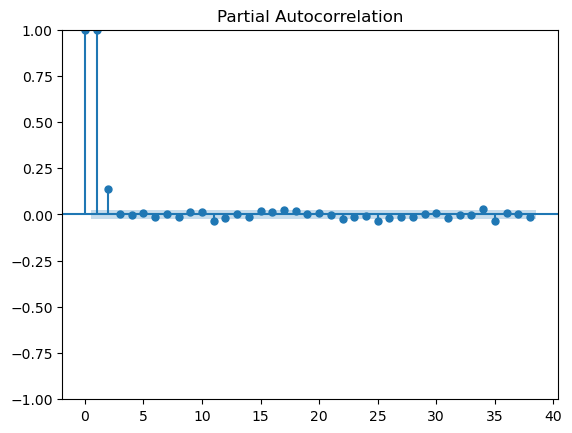

In [8]:
plot_acf(df['Ex_rate'])
plot_pacf(df['Ex_rate'])
plt.show()

- The ACF plot shows a **slow, gradual decay,** indicating the presence of an autoregressive (AR) component.
- The PACF plot shows **significant spikes up to lag 2,** suggesting **p = 2.**
- Since the series is non-stationary, **first-order differencing (d = 1)** is applied, and no strong evidence of MA component is observed, so **q = 0.**

# 2.)Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [9]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [10]:
print(len(train))
print(len(test))

4264
1066


In [11]:
arima= ARIMA(train['Ex_rate'], order=(2,1,0))
arima_fit=arima.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 4264
Model:                 ARIMA(2, 1, 0)   Log Likelihood               15196.007
Date:                Sat, 21 Mar 2026   AIC                         -30386.014
Time:                        19:55:22   BIC                         -30366.941
Sample:                             0   HQIC                        -30379.275
                               - 4264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0724      0.007    -10.385      0.000      -0.086      -0.059
ar.L2          0.0244      0.009      2.807      0.005       0.007       0.041
sigma2      4.692e-05   3.62e-07    129.618      0.0

# 3.)Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

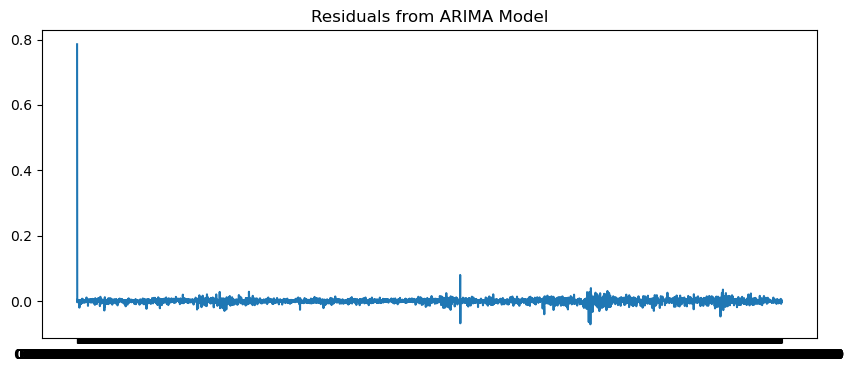

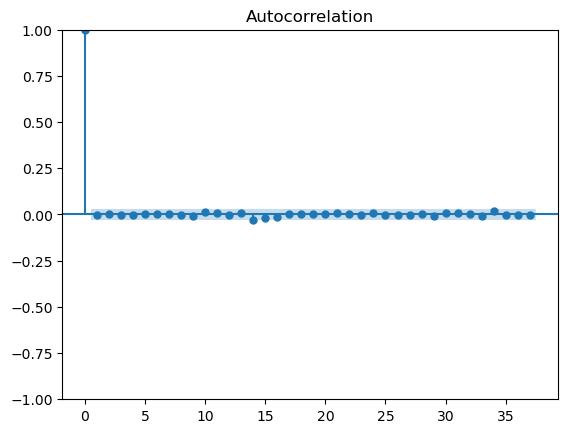

In [12]:
residuals = arima_fit.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals from ARIMA Model")
plt.show()

plot_acf(residuals)
plt.show()

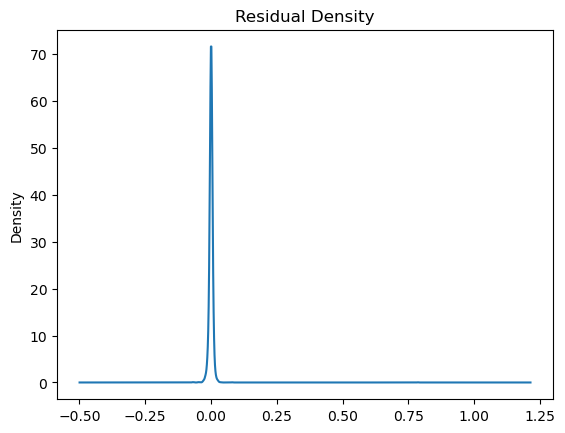

In [13]:
residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()

- The residual plot shows that the residuals are randomly distributed around zero with no clear pattern. 
- This indicates that the ARIMA model has captured the underlying structure of the data effectively 
and the model is adequate for forecasting.

# 4.)Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [14]:
forecast = arima_fit.forecast(steps=len(test))

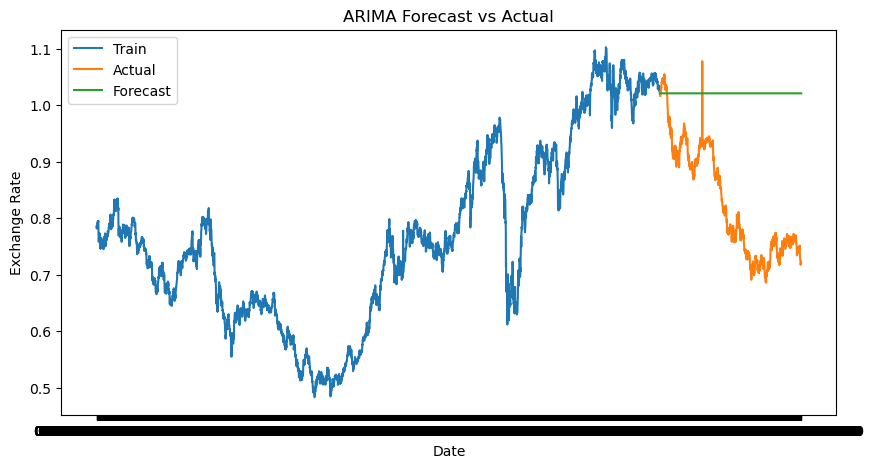

In [15]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

# 1.)Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

- **Exponential Smoothing models** are chosen based on the characteristics of the time series. 
- The data shows **trend but no clear seasonality,** so models handling trend were considered.
- Therefore, **Holt’s Linear Exponential Smoothing model** was chosen as it effectively captures trend without requiring seasonal components.

# 2.)Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.

- A manual search combined with AIC was used to compare different Exponential Smoothing models with varying **trend components (additive, multiplicative, and none).**
- The model with the lowest AIC value was selected as the optimal model, as it provides the best trade-off between model complexity and goodness of fit.

In [17]:
# Hyper Parameter Tuning
trends = ['add', 'mul', None]
best_aic = float("inf")
best_model = None
best_trend = None

for t in trends:
    try:
        model = ExponentialSmoothing(train['Ex_rate'], trend=t, seasonal=None)
        fit = model.fit()
        
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_model = fit
            best_trend = t
    except:
        continue
print("Best trend:", best_trend)

Best trend: None


- The model without a trend component was selected as it had the **lowest AIC value.** 
- This **indicates that including a trend component did not significantly improve the model performance,** and a simpler model provides a better fit for the data.

# 3.) Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.

In [18]:
model_exp= ExponentialSmoothing(train['Ex_rate'],trend=None,seasonal=None)
fit_exp = model_exp.fit(optimized=True)
print(fit_exp.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 4264
Model:             ExponentialSmoothing   SSE                              0.200
Optimized:                         True   AIC                         -42493.107
Trend:                             None   BIC                         -42480.391
Seasonal:                          None   AICC                        -42493.098
Seasonal Periods:                  None   Date:                 Sat, 21 Mar 2026
Box-Cox:                          False   Time:                         19:58:44
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9279215                alpha                 True
initial_level              0.78534

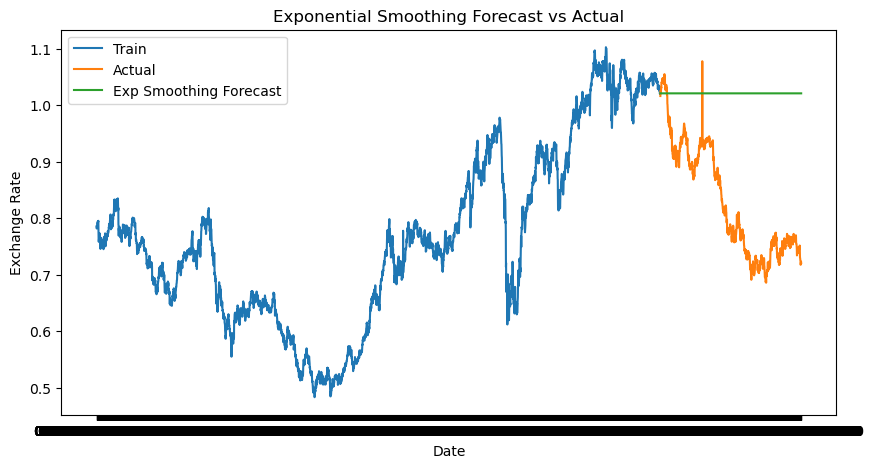

In [19]:
forecast_exp = fit_exp.forecast(steps=len(test))
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index,forecast_exp, label='Exp Smoothing Forecast')

plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

- The forecasted values from the Exponential Smoothing model are plotted against the actual values.
- The model **reasonably follows the overall trend of the data,** though some deviations are observed in short-term fluctuations.

# **Part 4: Evaluation and Comparison**

# 1.)Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

In [20]:
# ARIMA
mae_arima = mean_absolute_error(test['Ex_rate'], forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Ex_rate'], forecast))
mape_arima = np.mean(np.abs((test['Ex_rate'].values - forecast.values) / test['Ex_rate'].values)) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE: 0.19375437637686208
ARIMA RMSE: 0.215603274068954
ARIMA MAPE: 25.003749070335186


In [21]:
# Exponential Smoothing
mae_exp = mean_absolute_error(test['Ex_rate'], forecast_exp)
rmse_exp = np.sqrt(mean_squared_error(test['Ex_rate'], forecast_exp))
mape_exp = np.mean(np.abs((test['Ex_rate'].values - forecast_exp.values) / test['Ex_rate'].values)) * 100

print("Exponential Smoothing MAE:", mae_exp)
print("Exponential Smoothing RMSE:", rmse_exp)
print("Exponential Smoothing MAPE:", mape_exp)

Exponential Smoothing MAE: 0.19373309610588088
Exponential Smoothing RMSE: 0.21558244225673068
Exponential Smoothing MAPE: 25.001092214662705


# 2.) Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

**Model Comparison**

- The ARIMA model produced **MAE=0.1937, RMSE=0.2156, and MAPE ≈ 25%,** while the Exponential Smoothing model showed **similar error values,** indicating comparable forecasting performance.
- ARIMA models are effective in capturing **autocorrelation and temporal dependencies** in time series data, but they require careful parameter selection (p, d, q) and assume stationarity, making them more complex.
- Exponential Smoothing models are **simpler and computationally efficient,** adapting well to recent changes, but they may not capture complex patterns and short-term fluctuations as effectively.
- Overall, both models perform similarly, but **ARIMA is slightly more reliable** due to its ability to better model underlying data patterns.

# 3.) Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

**Conclusion**
- Both **ARIMA and Exponential Smoothing models** were applied and evaluated using MAE, RMSE, and MAPE metrics.
- The results show that both models achieved **similar performance,** with MAPE values around 25%, indicating acceptable forecasting accuracy.
- ARIMA effectively captures **temporal dependencies and underlying patterns,** while Exponential Smoothing is simpler but less effective in handling short-term fluctuations.
- Based on the comparison, **ARIMA performs slightly better and is more reliable** for forecasting exchange rates in this dataset.
- Therefore, ARIMA is considered the **preferred model** for this analysis.

# **--------------------------------------THE END------------------------------------------**